In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
warnings.filterwarnings("ignore")

df = pd.read_csv("saida/trechos_913.csv")

In [10]:
# ─────────────────────────────────────────────
# 1. CARREGAMENTO E FILTRAGEM BASE
# ─────────────────────────────────────────────

df['t_saida'] = pd.to_datetime(df['t_saida'])
df['t_chegada'] = pd.to_datetime(df['t_chegada'])

df = df[df["pulos"] == 0].copy()
df = df[df.notna().all(axis=1)].copy()

# Identifica e remove os trechos onde o ônibus está saindo do terminal
mask_terminal = df['nome_a'].str.contains("Terminal|Ponto Final", case=False, na=False)


df = df[~mask_terminal].copy()
print(f"Registros após remover saídas de terminal: {len(df)}")

df = df.sort_values('t_saida').reset_index(drop=True)

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
df["segmento"] = df["stop_a"] + "__" + df["stop_b"]
df["segmento"] = df["segmento"].astype("category")
df["tipo_dia"] = df["tipo_dia"].astype("category")

# Adicionando lag de 1 para o target "segundos"
df["segundos_lag1"] = df.groupby("segmento")["segundos"].shift(1)
df = df.dropna(subset=["segundos_lag1"]).reset_index(drop=True)

# ─────────────────────────────────────────────
# 3. DEFINIÇÃO DE FEATURES E TARGET
# ─────────────────────────────────────────────
FEATURES = [
    "segmento",                 
    "hora_sin", "hora_cos",     
    "dia_sin",  "dia_cos",      
    "tipo_dia",                 
    "chuva", "temp_max",
    "segundos_lag1"
]
TARGET = "segundos"

X = df[FEATURES]
y = df[TARGET]

print(f"\nFeatures mapeadas: {FEATURES}")

Registros após remover saídas de terminal: 89809

Features mapeadas: ['segmento', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'tipo_dia', 'chuva', 'temp_max', 'segundos_lag1']


In [11]:
# ─────────────────────────────────────────────
# 4. COMPARAÇÃO DE MODELOS
# ─────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

modelos = {
    "XGBoost (MAE Loss)": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        objective='reg:absoluteerror',
        enable_categorical=True,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        categorical_features=[0, 5],    # Índices de 'segmento' e 'tipo_dia'
        random_state=42
    )
}

for nome, modelo in modelos.items():
    print(f"\n[{nome}] - Iniciando Validação Cruzada Temporal...")
    maes = []
    r2s  = []

    for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        modelo.fit(X_train, y_train)
        preds = modelo.predict(X_test)

        erro_mae = mean_absolute_error(y_test, preds)
        score_r2  = r2_score(y_test, preds)

        maes.append(erro_mae)
        r2s.append(score_r2)
        print(f"  Fold {fold} -> MAE: {erro_mae:.1f}s | R²: {score_r2:.3f}")

    print(f"==> {nome} FINAL -> MAE Médio: {np.mean(maes):.1f}s | R² Médio: {np.mean(r2s):.3f}")



[XGBoost (MAE Loss)] - Iniciando Validação Cruzada Temporal...
  Fold 1 -> MAE: 28.0s | R²: 0.665
  Fold 2 -> MAE: 27.7s | R²: 0.691
  Fold 3 -> MAE: 26.9s | R²: 0.707
  Fold 4 -> MAE: 27.0s | R²: 0.705
  Fold 5 -> MAE: 27.8s | R²: 0.703
==> XGBoost (MAE Loss) FINAL -> MAE Médio: 27.5s | R² Médio: 0.694

[HistGradientBoosting] - Iniciando Validação Cruzada Temporal...
  Fold 1 -> MAE: 29.7s | R²: 0.678
  Fold 2 -> MAE: 29.5s | R²: 0.715
  Fold 3 -> MAE: 29.2s | R²: 0.717
  Fold 4 -> MAE: 28.7s | R²: 0.731
  Fold 5 -> MAE: 29.2s | R²: 0.731
==> HistGradientBoosting FINAL -> MAE Médio: 29.3s | R² Médio: 0.714


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Melhor combinação encontrada: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Menor MAE médio alcançado:    27.4s

Top 10 combinações:
 param_max_depth  param_learning_rate  param_n_estimators       MAE  std_test_score
               7                 0.10                 200 27.355379        0.521113
               8                 0.05                 200 27.377449        0.572737
               7                 0.10                 300 27.382435        0.505765
               7                 0.05                 500 27.391617        0.510502
               7                 0.05                 300 27.394268        0.497836
               7                 0.10                 500 27.415422        0.501135
               7                 0.05                 200 27.448522        0.505930
               8                 0.05                 300 27.449642        0.595029
               5                 0

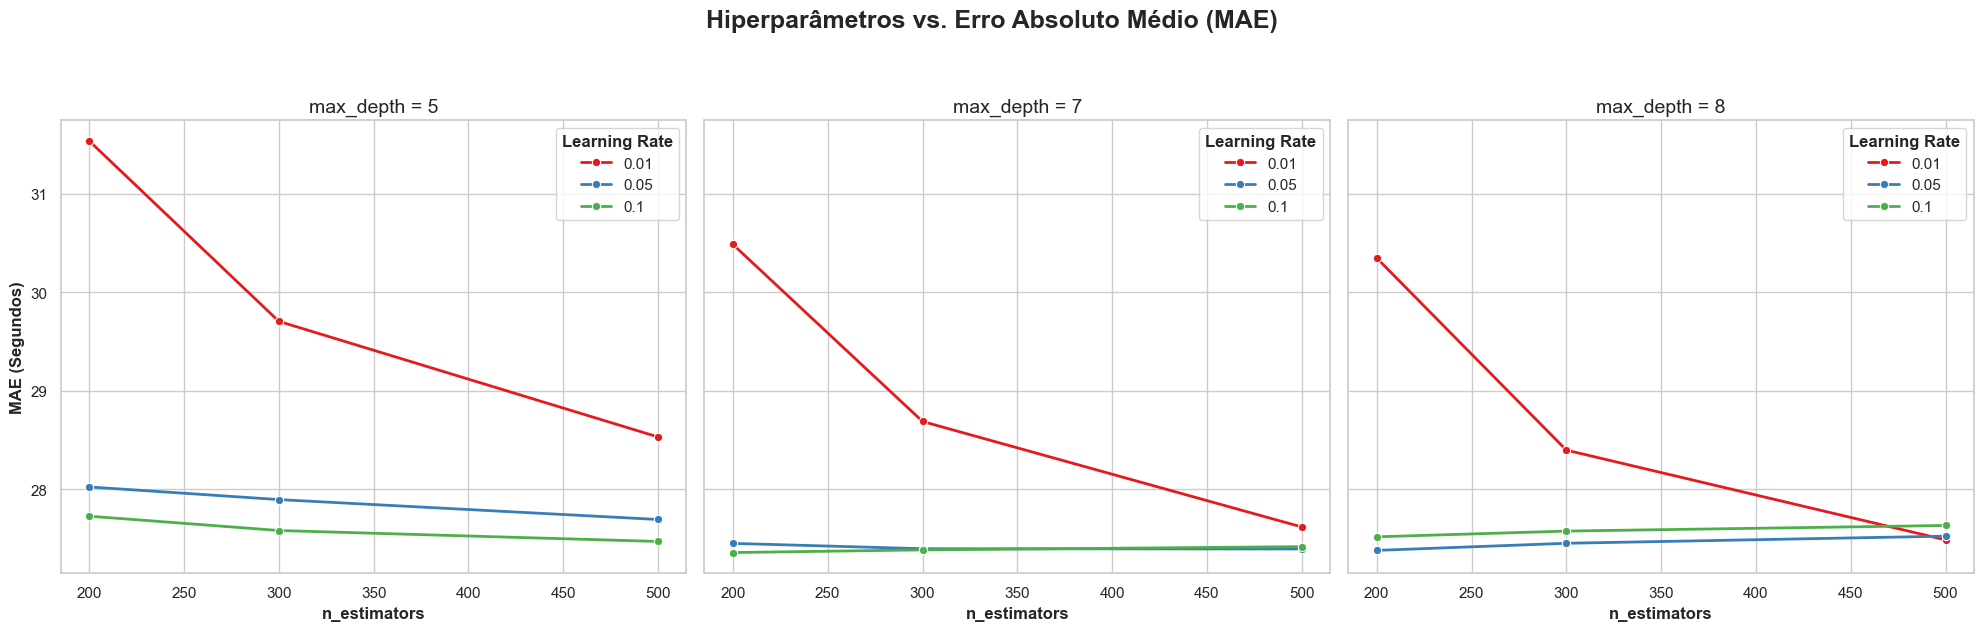

In [12]:
# ─────────────────────────────────────────────
# 5. TUNING DE HIPERPARÂMETROS
# ─────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    'max_depth':     [5, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [200, 300, 500]
}

xgb_base = XGBRegressor(
    objective='reg:absoluteerror',
    enable_categorical=True,
    n_jobs=1,
    random_state=42,
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"\nMelhor combinação encontrada: {grid_search.best_params_}")
print(f"Menor MAE médio alcançado:    {-grid_search.best_score_:.1f}s")

resultados_top = pd.DataFrame(grid_search.cv_results_)
resultados_top['MAE'] = -resultados_top['mean_test_score']
top10 = resultados_top.nsmallest(10, 'MAE')[[
    'param_max_depth', 'param_learning_rate',
    'param_n_estimators', 'MAE', 'std_test_score'
]]
print("\nTop 10 combinações:")
print(top10.to_string(index=False))

# ─────────────────────────────────────────────
# 6. VISUALIZAÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# ─────────────────────────────────────────────
resultados_grid = pd.DataFrame(grid_search.cv_results_)
resultados_grid['MAE'] = -resultados_grid['mean_test_score']

profundidades = param_grid['max_depth']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(profundidades), figsize=(20, 6), sharey=True)
fig.suptitle("Hiperparâmetros vs. Erro Absoluto Médio (MAE)", fontsize=18, fontweight='bold', y=1.05)

for i, depth in enumerate(profundidades):
    dados_plot = resultados_grid[resultados_grid['param_max_depth'] == depth]

    sns.lineplot(
        data=dados_plot,
        x='param_n_estimators',
        y='MAE',
        hue='param_learning_rate',
        marker='o',
        palette='Set1',
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(f"max_depth = {depth}", fontsize=14)
    axes[i].set_xlabel("n_estimators", fontweight='bold')
    if i == 0:
        axes[i].set_ylabel("MAE (Segundos)", fontweight='bold')
    else:
        axes[i].set_ylabel("")

    axes[i].legend(title="Learning Rate", title_fontproperties={'weight': 'bold'})

plt.tight_layout()
plt.show()


In [13]:
# ─────────────────────────────────────────────
# 7. VALIDAÇÃO CRUZADA FINAL COM MELHORES PARÂMETROS
# ─────────────────────────────────────────────
best_params = grid_search.best_params_
print(f"Parâmetros selecionados pelo GridSearch: {best_params}")
print()

modelo_final = XGBRegressor(
    **best_params,
    objective='reg:absoluteerror',
    enable_categorical=True,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

maes_final = []
r2s_final  = []
y_test_list  = []
preds_list   = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    X_train, X_test   = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test_f = y.iloc[train_index], y.iloc[test_index]

    modelo_final.fit(X_train, y_train)
    preds_f = modelo_final.predict(X_test)

    mae = mean_absolute_error(y_test_f, preds_f)
    r2  = r2_score(y_test_f, preds_f)

    maes_final.append(mae)
    r2s_final.append(r2)
    y_test_list.append(y_test_f)
    preds_list.append(preds_f)
    print(f"Fold {fold} -> MAE: {mae:.1f}s | R²: {r2:.3f}")

print(f"\n==> Modelo Final -> MAE Médio: {np.mean(maes_final):.1f}s | R² Médio: {np.mean(r2s_final):.3f}")

# Agrega todos os folds — usado pelos gráficos a seguir
y_test = pd.concat(y_test_list)
preds  = np.concatenate(preds_list)


Parâmetros selecionados pelo GridSearch: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Fold 1 -> MAE: 28.1s | R²: 0.667
Fold 2 -> MAE: 27.5s | R²: 0.698
Fold 3 -> MAE: 26.9s | R²: 0.706
Fold 4 -> MAE: 26.7s | R²: 0.708
Fold 5 -> MAE: 27.5s | R²: 0.709

==> Modelo Final -> MAE Médio: 27.4s | R² Médio: 0.698


In [14]:
# ─────────────────────────────────────────────
# 8. IMPORTÂNCIA DAS FEATURES (modelo final)
# ─────────────────────────────────────────────
modelo_final.fit(X, y)

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("--- IMPORTÂNCIA DAS FEATURES (XGBoost — com os melhores parâmetros) ---")
print(importancias.round(3).to_string())


--- IMPORTÂNCIA DAS FEATURES (XGBoost — com os melhores parâmetros) ---
segmento         0.724
hora_cos         0.063
hora_sin         0.062
tipo_dia         0.046
dia_sin          0.042
segundos_lag1    0.034
temp_max         0.013
dia_cos          0.009
chuva            0.008


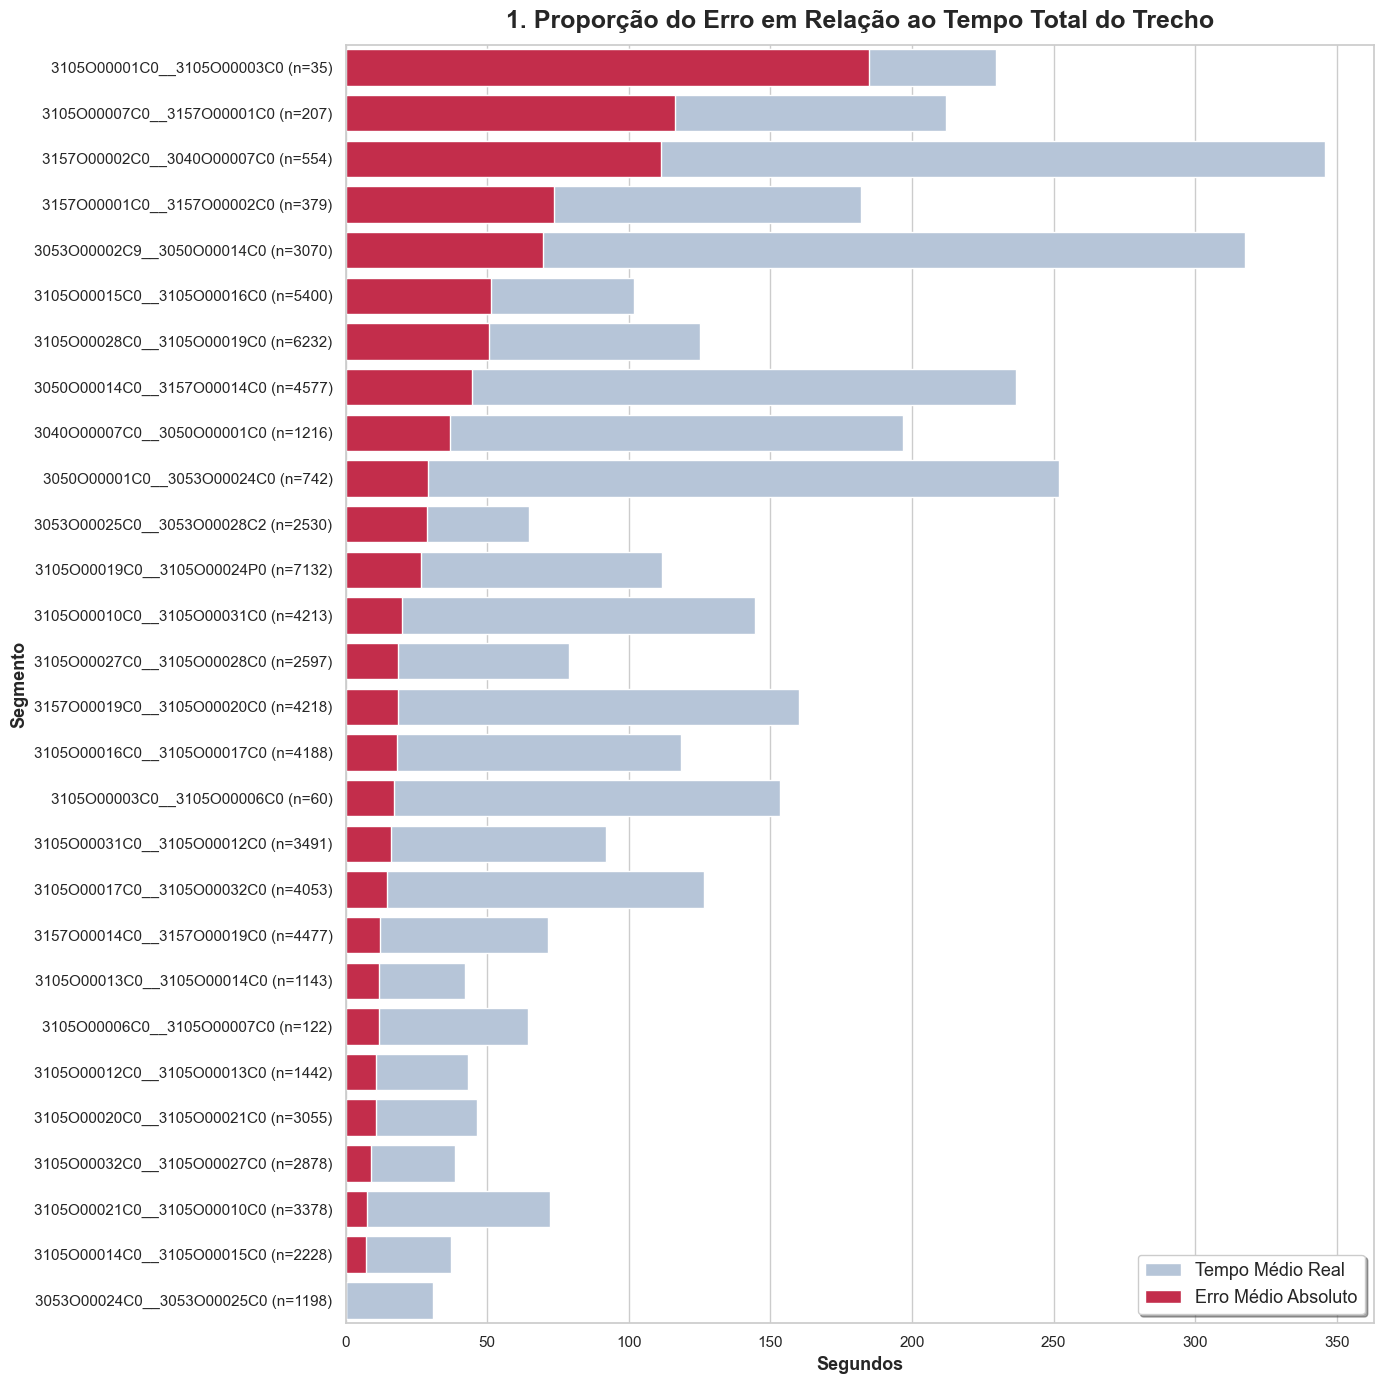

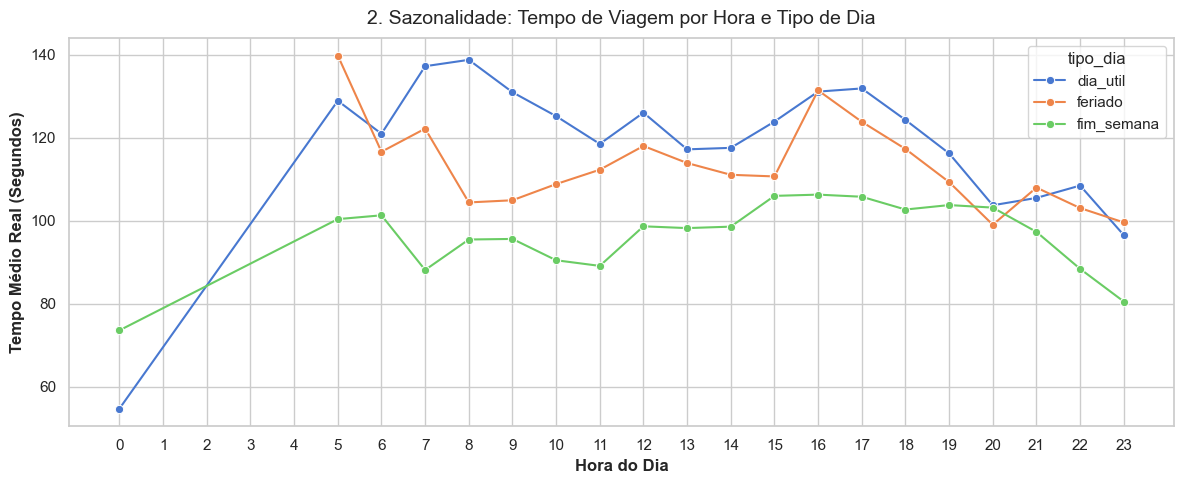

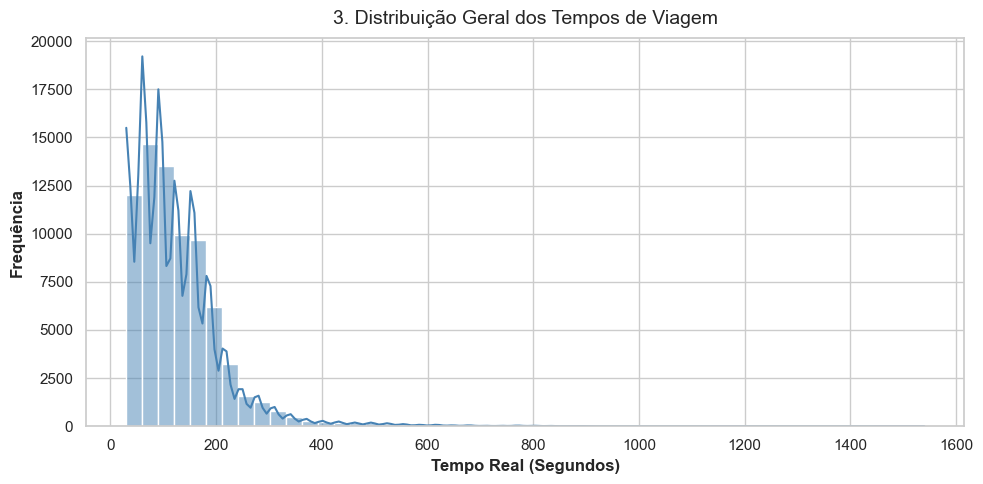

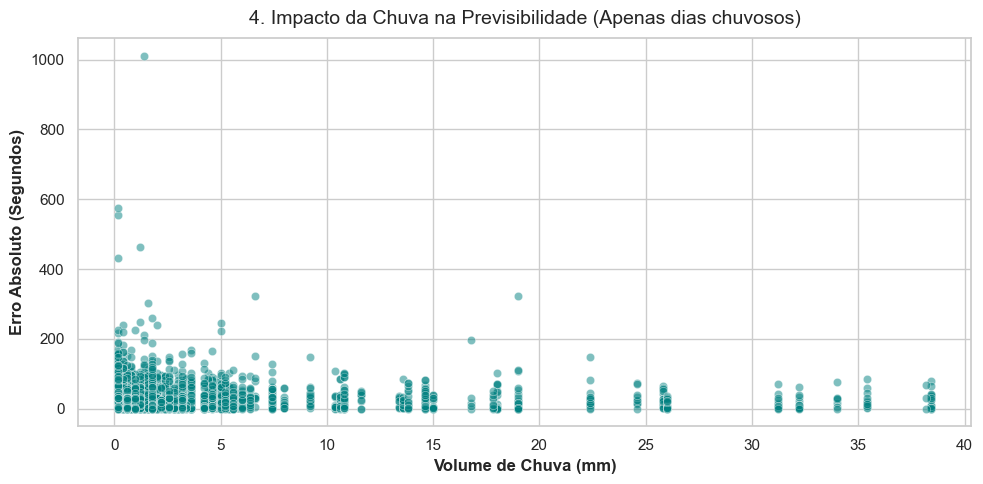

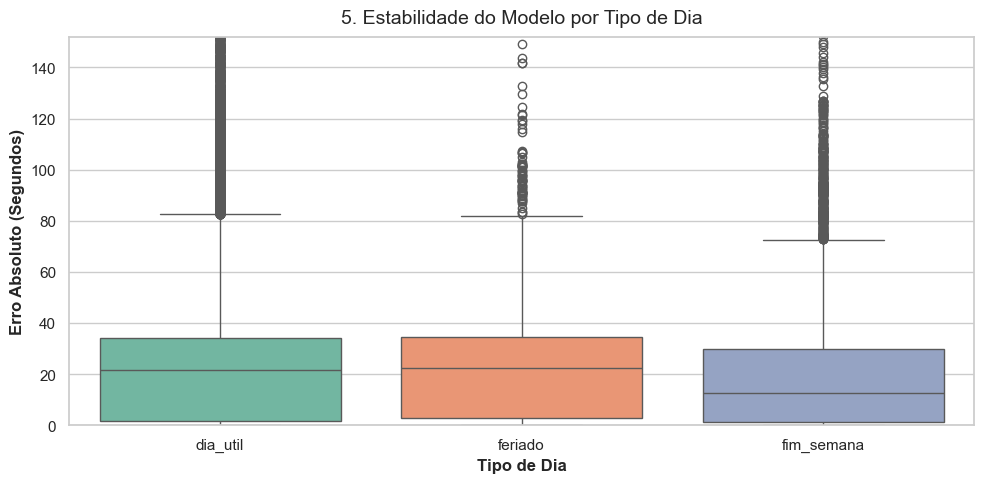

In [17]:
import matplotlib.gridspec as gridspec

sns.set_theme(style="whitegrid", palette="muted")

# Preparação dos dados de Erros
df_erros = df.loc[y_test.index].copy()
df_erros['previsao'] = preds
df_erros['erro_absoluto'] = np.abs(df_erros['segundos'] - df_erros['previsao'])
df_erros['hora'] = df_erros['t_saida'].dt.hour

# ══════════════════════════════════════════════════════════════════════════════
# 1. Proporção do Erro em Relação ao Tempo Total do Trecho
# ══════════════════════════════════════════════════════════════════════════════
erros_segmento = df_erros.groupby('segmento', observed=True).agg(
    erro_medio=('erro_absoluto', 'mean'),
    tempo_medio=('segundos', 'mean'),
    contagem=('erro_absoluto', 'count')
).query('contagem > 10').sort_values('erro_medio', ascending=False).reset_index()

erros_segmento['segmento_label'] = erros_segmento['segmento'].astype(str) + " (n=" + erros_segmento['contagem'].astype(str) + ")"

n_segmentos = len(erros_segmento)
altura = max(8, n_segmentos * 0.5)

fig1, ax1 = plt.subplots(figsize=(14, altura))

sns.barplot(data=erros_segmento, x='tempo_medio', y='segmento_label', ax=ax1, color='#B0C4DE', label='Tempo Médio Real')
sns.barplot(data=erros_segmento, x='erro_medio', y='segmento_label', ax=ax1, color='#DC143C', label='Erro Médio Absoluto')

ax1.set_title("1. Proporção do Erro em Relação ao Tempo Total do Trecho", fontsize=18, pad=12, fontweight='bold')
ax1.set_xlabel("Segundos", fontweight='bold', fontsize=13)
ax1.set_ylabel("Segmento", fontweight='bold', fontsize=13)
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='x', labelsize=11)
ax1.legend(loc='lower right', fontsize=13, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. Sazonalidade: Tempo de Viagem por Hora e Tipo de Dia
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_erros, x='hora', y='segundos', hue='tipo_dia', estimator='mean', errorbar=None, marker='o', ax=ax2)
ax2.set_title("2. Sazonalidade: Tempo de Viagem por Hora e Tipo de Dia", fontsize=14, pad=10)
ax2.set_xlabel("Hora do Dia", fontweight='bold')
ax2.set_ylabel("Tempo Médio Real (Segundos)", fontweight='bold')
ax2.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 3. Distribuição Geral dos Tempos de Viagem
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.histplot(df_erros['segundos'], bins=50, kde=True, ax=ax3, color='steelblue')
ax3.set_title("3. Distribuição Geral dos Tempos de Viagem", fontsize=14, pad=10)
ax3.set_xlabel("Tempo Real (Segundos)", fontweight='bold')
ax3.set_ylabel("Frequência", fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. Impacto da Chuva na Previsibilidade
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df_erros[df_erros['chuva'] > 0], x='chuva', y='erro_absoluto', alpha=0.5, ax=ax4, color='teal')
ax4.set_title("4. Impacto da Chuva na Previsibilidade (Apenas dias chuvosos)", fontsize=14, pad=10)
ax4.set_xlabel("Volume de Chuva (mm)", fontweight='bold')
ax4.set_ylabel("Erro Absoluto (Segundos)", fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. Estabilidade do Modelo por Tipo de Dia
# ══════════════════════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_erros, x='tipo_dia', y='erro_absoluto', ax=ax5, palette="Set2")
ax5.set_title("5. Estabilidade do Modelo por Tipo de Dia", fontsize=14, pad=10)
ax5.set_xlabel("Tipo de Dia", fontweight='bold')
ax5.set_ylabel("Erro Absoluto (Segundos)", fontweight='bold')
ax5.set_ylim(0, df_erros['erro_absoluto'].quantile(0.99))
plt.tight_layout()
plt.show()